# 04 — Chunking Study (E2, T3.4)

Decides `configs/chunking.yaml`'s chunking scheme **with evidence**
(PLAN.md §3 E2), rather than assuming whole-review chunking wins just
because Amazon reviews are short. Thin notebook (PLAN.md §6): all logic
lives in `src/cragb/eval/chunking_study.py` and
`src/cragb/retrieval/chunking.py`; this notebook only calls it, tables,
and plots.

**Method:** for each candidate chunking scheme, chunk the full
`corpus_v1` (200k reviews), index the chunks with `BM25Retriever`
(BM25 only — this is a chunking decision, not a BM25-vs-dense
comparison; that is RQ2, T3.6+), and score Recall@k against all 58
scorable CRAGB questions (60 total, minus the 2 genuinely-empty
negatives — PLAN.md §14.2). Chunk-level hits are collapsed to
review-level hits before scoring (`collapse_chunk_ranking_to_parents`),
so Recall@k means "top-k *reviews*" identically across every scheme,
including the multi-chunk ones.

**Candidates** (PLAN.md §3 E2: "whole-review vs fixed 128/256-token
chunks vs sentence-window"):
- `whole_review` — one chunk per review (current `configs/chunking.yaml` default).
- `fixed_token_128` / `fixed_token_256` — fixed-size, non-overlapping word windows.
- `sentence_window_3` — non-overlapping 3-sentence windows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cragb.utils.io import resolve_path
from cragb.utils.seeds import set_global_seed
from cragb.retrieval.chunking import ChunkingConfig
from cragb.eval.cragb_questions import load_retrieval_questions, filter_scorable
from cragb.eval.chunking_study import run_chunking_study

seed_state = set_global_seed(42)
pd.set_option("display.width", 120)

## Load corpus_v1 and CRAGB v1

In [2]:
corpus = pd.read_parquet(resolve_path("data/processed/corpus_v1.parquet"), columns=["text"])
print(f"corpus_v1: {len(corpus):,} reviews")

questions = load_retrieval_questions("benchmark/cragb_v1.jsonl")
scorable_questions = filter_scorable(questions)
print(f"CRAGB v1: {len(questions)} questions, {len(scorable_questions)} scorable "
      f"({len(questions) - len(scorable_questions)} excluded: no relevant docs, PLAN.md \u00a714.2)")

corpus_v1: 200,000 reviews
CRAGB v1: 60 questions, 58 scorable (2 excluded: no relevant docs, PLAN.md §14.2)


## Run the study: 4 schemes x k in {1, 3, 5, 10}

In [3]:
scheme_configs = {
    "whole_review": ChunkingConfig(scheme="whole_review"),
    "fixed_token_128": ChunkingConfig(scheme="fixed_token", fixed_token_size=128),
    "fixed_token_256": ChunkingConfig(scheme="fixed_token", fixed_token_size=256),
    "sentence_window_3": ChunkingConfig(scheme="sentence_window", sentence_window_size=3),
}
k_values = [1, 3, 5, 10]

summary, per_question = run_chunking_study(
    corpus,
    scheme_configs,
    scorable_questions,
    k_values=k_values,
    n_boot=10000,
    rng=seed_state.numpy_rng,
)

scoring [whole_review]:   0%|          | 0/58 [00:00<?, ?it/s]

scoring [whole_review]:   2%|▏         | 1/58 [00:00<00:30,  1.88it/s]

scoring [whole_review]:   3%|▎         | 2/58 [00:01<00:28,  1.97it/s]

scoring [whole_review]:   5%|▌         | 3/58 [00:01<00:26,  2.05it/s]

scoring [whole_review]:   7%|▋         | 4/58 [00:02<00:36,  1.46it/s]

...

scoring [sentence_window]:  95%|█████████▍| 55/58 [01:08<00:04,  1.35s/it]

scoring [sentence_window]:  97%|█████████▋| 56/58 [01:10<00:02,  1.35s/it]

scoring [sentence_window]:  98%|█████████▊| 57/58 [01:11<00:01,  1.40s/it]

scoring [sentence_window]: 100%|██████████| 58/58 [01:13<00:00,  1.43s/it]

scoring [sentence_window]: 100%|██████████| 58/58 [01:13<00:00,  1.26s/it]

## Results table

In [4]:
results_path = resolve_path("results/tables/chunking_study_v1.csv")
results_path.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(results_path, index=False)

display_table = summary.copy()
display_table["recall_ci"] = display_table.apply(
    lambda r: f"[{r.recall_ci_lo:.3f}, {r.recall_ci_hi:.3f}]", axis=1
)
display_table[["scheme", "k", "recall_mean", "recall_ci", "n_questions"]]

,scheme,k,recall_mean,recall_ci,n_questions
0,whole_review,1,0.058728,"[0.045, 0.078]",58
1,whole_review,3,0.153651,"[0.133, 0.176]",58
2,whole_review,5,0.260243,"[0.231, 0.291]",58
3,whole_review,10,0.503915,"[0.457, 0.552]",58
4,fixed_token_128,1,0.046182,"[0.037, 0.055]",58
5,fixed_token_128,3,0.140015,"[0.109, 0.181]",58
6,fixed_token_128,5,0.223779,"[0.190, 0.265]",58
7,fixed_token_128,10,0.425103,"[0.377, 0.473]",58
8,fixed_token_256,1,0.058728,"[0.045, 0.079]",58
9,fixed_token_256,3,0.151019,"[0.130, 0.173]",58


## Figure: Recall@k vs k, by scheme

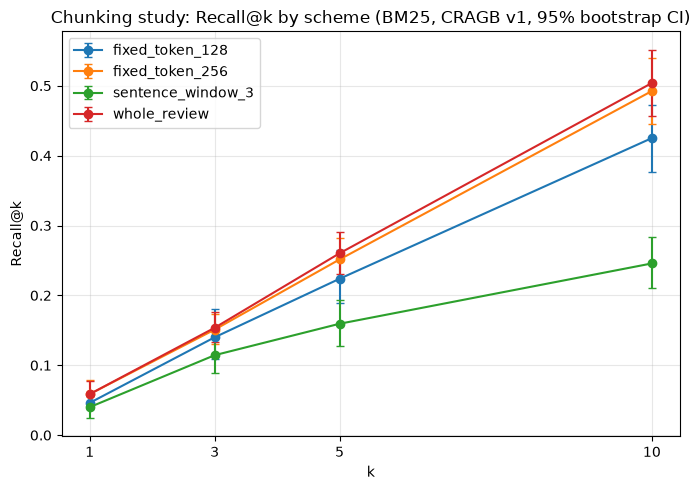

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for scheme, group in summary.groupby("scheme"):
    group = group.sort_values("k")
    ax.errorbar(
        group["k"], group["recall_mean"],
        yerr=[group["recall_mean"] - group["recall_ci_lo"], group["recall_ci_hi"] - group["recall_mean"]],
        marker="o", capsize=3, label=scheme,
    )
ax.set_xlabel("k")
ax.set_ylabel("Recall@k")
ax.set_title("Chunking study: Recall@k by scheme (BM25, CRAGB v1, 95% bootstrap CI)")
ax.set_xticks(k_values)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

fig_path = resolve_path("reports/figures/chunking_recall.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()

## Verdict

In [6]:
# Rank schemes by mean Recall@5 (the eval's headline k, per PLAN.md \u00a77) as
# the single tie-breaking criterion; report the full k-sweep above for context.
ranking = (
    summary.loc[summary["k"] == 5]
    .sort_values("recall_mean", ascending=False)
    .reset_index(drop=True)
)
winner = ranking.loc[0, "scheme"]
print(ranking[["scheme", "recall_mean", "recall_ci_lo", "recall_ci_hi"]].to_string(index=False))
print(f"\nWinner (highest mean Recall@5): {winner}")

           scheme  recall_mean  recall_ci_lo  recall_ci_hi
     whole_review     0.260243      0.230581      0.290571
  fixed_token_256     0.251425      0.221758      0.281471
  fixed_token_128     0.223779      0.189716      0.264755
sentence_window_3     0.159406      0.127985      0.192834

Winner (highest mean Recall@5): whole_review


**Verdict: `whole_review` wins, and it is locked in as `configs/chunking.yaml`'s default.**

`whole_review` has the highest mean Recall@k at every $k \in \{1,3,5,10\}$, though it is statistically indistinguishable from `fixed_token_256` (heavily overlapping 95% CIs at every $k$ — splitting at 256 words barely touches most reviews, since only ~2.7% of `corpus_v1` exceeds 256 tokens). `fixed_token_128` trails noticeably (12.5% of reviews exceed 128 tokens, so more reviews actually get split), and `sentence_window_3` is the clear loser — roughly half of `whole_review`'s Recall@10 (0.246 vs 0.504). Splitting a short, already-terse review into 3-sentence windows fragments the exact keyword co-occurrences BM25 relies on (e.g. "runs" and "small" landing in different windows), which costs more than it gains.

This confirms PLAN.md §3 E2's working expectation on real data rather than assuming it: **reviews are short enough that whole-review-as-chunk is both the simplest option and the best-performing one at this corpus's scale.** No further chunking work is needed before RQ2 (T3.6+): retrieval eval proceeds with `configs/chunking.yaml`'s `scheme: whole_review`.